# Simple Parallel Workflow
- Given runs, balls, No of 4s and 6s hit, you will need to compute the below 3 metrices
    - Strike Rate
    - Boundary Percentage
    - Balls per boundary
- All these 3 are independent tasks thus must be executed in parallel
- Then aggregate these 3 quantities and then generate the summary
- Workflow
    - START -> (Strike Rate, Boundary Percentage, Balls per boundary) -> Summary -> END


In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class State(TypedDict):
    runs: int
    balls: int
    sixes: int
    fours: int

    strike_rate: float
    boundary_percentage: float
    balls_per_boundary: float
    summary: str

# Define Graph

In [3]:
graph = StateGraph(State)

# Function definations

In [4]:
def strike_rate(state: State) -> State:
    state["strike_rate"] = (state["runs"]/ state["balls"])*100
    return state

def balls_per_boundary(state: State)->State:
    state["balls_per_boundary"] = state["balls"]/(state["fours"]+state["sixes"])
    return state

def boundary_percentage(state: State)->State:
    state["boundary_percentage"] = (((state["fours"]*4 ) + (state["sixes"]*6))/state["runs"])*100
    return state


def summary(state: State) -> State:
    state["summary"] = f"""
        Strike Rate: {state["strike_rate"]}, 
        balls_per_boundary: {state["balls_per_boundary"]}, 
        boundary_percentage: {state["boundary_percentage"]}
    """
    return state

# Creating Nodes

In [5]:
graph.add_node("summary", summary)
graph.add_node("strike_rate", strike_rate)
graph.add_node("balls_per_boundary", balls_per_boundary)
graph.add_node("boundary_percentage", boundary_percentage)

# Creating edges
- Here the START Node goes to 3 other nodes i.e. strike_rate, balls_per_boundary and boundary_percentage
- Each of the 3 nodes futher connect to summary Node
- Finally the summary node connects to the END Node

In [6]:
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "balls_per_boundary")
graph.add_edge(START, "boundary_percentage")

graph.add_edge("strike_rate", "summary")
graph.add_edge("balls_per_boundary", "summary")
graph.add_edge("boundary_percentage", "summary")

graph.add_edge("summary", END)

# Compiling the graph

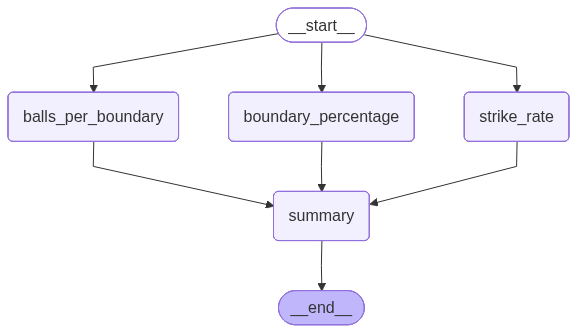

In [7]:
workflow = graph.compile()
workflow

# Invoking the graph

In [8]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

final_state = workflow.invoke(initial_state)
final_state

InvalidUpdateError: At key 'runs': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

- This error is occuring as the same state parameters i.e. runs, sixes, fours, and balls are being used parallely by the 3 parallely running nodes(although no edit is done on these parameters), the summary node will not know which state to use as all 3 nodes will return a state
- So instead of returning the entire state, just return only partial state i.e. strike_rate() must just return "strike_rate" and not return complete state


In [9]:
def strike_rate(state: State) -> State:
    strike_rate = (state["runs"]/ state["balls"])*100
    return {"strike_rate":strike_rate}

def balls_per_boundary(state: State)->State:
    balls_per_boundary = state["balls"]/(state["fours"]+state["sixes"])
    return {"balls_per_boundary":balls_per_boundary}

def boundary_percentage(state: State)->State:
    boundary_percentage = (((state["fours"]*4 ) + (state["sixes"]*6))/state["runs"])*100
    return {"boundary_percentage":boundary_percentage}


def summary(state: State) -> State:
    summary = f"""
        Strike Rate: {state["strike_rate"]}, 
        balls_per_boundary: {state["balls_per_boundary"]}, 
        boundary_percentage: {state["boundary_percentage"]}
    """
    return {"summary": summary}

In [10]:
# Defining the graph
graph = StateGraph(State)

# Create Nodes
graph.add_node("summary", summary)
graph.add_node("strike_rate", strike_rate)
graph.add_node("balls_per_boundary", balls_per_boundary)
graph.add_node("boundary_percentage", boundary_percentage)

# Adding edges
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "balls_per_boundary")
graph.add_edge(START, "boundary_percentage")

graph.add_edge("strike_rate", "summary")
graph.add_edge("balls_per_boundary", "summary")
graph.add_edge("boundary_percentage", "summary")

graph.add_edge("summary", END)

# Compiling the graph to create a workflow
workflow = graph.compile()

# Invoking the workflow
final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls': 50,
 'sixes': 4,
 'fours': 6,
 'strike_rate': 200.0,
 'boundary_percentage': 48.0,
 'balls_per_boundary': 5.0,
 'summary': '\n        Strike Rate: 200.0, \n        balls_per_boundary: 5.0, \n        boundary_percentage: 48.0\n    '}